<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [10]</a>'.</span>

# OncoBridge-MMCAT v7 — 4-Modality Pan-Cancer Classifier
## Clean rebuild. Evidence-based. No overengineering.

### What we know works (from all previous versions):
| Setting | Value | Why |
|---------|-------|-----|
| embed_dim | 384 | v3 got 91.94% with this — v5's 512 → 85M params → overfit |
| encoder layers | 6 | v3 proven |
| cross-attn layers | 4 | v3 proven |
| ff_dim | 1536 | v3 proven |
| OneCycleLR | ✅ | CosineRestarts in v5 → 83.95%. OneCycleLR wins. |
| CE + class weights | ✅ | v3 CE beat v4 focal. Gamma hurts with class weights combined. |
| Mixup prob | 0.5 | v3 proven — do NOT reduce when model is large |
| batch=64, accum=8 | 512 eff. | Proper GPU utilization |

### New in v7 (biologically correct):
- **Mutation: NO scaling** — it's binary (0/1). StandardScaler turns wildtype into negative floats. That's wrong.
- **Methylation: NO scaling** — beta values are already bounded [0,1]. StandardScaler distorts this.  
- **CNV: MaxAbsScaler** — preserves 0 (normal copy number), just scales -2/+2 to -1/+1.
- **mRNA: StandardScaler** — continuous log-expression, this is correct.
- **Gene importance gate init=1.5** — sigmoid(1.5)=0.82 (mostly open at start, learns to close noisy genes)
- **4th modality: DNA Methylation** — epigenetic silencing signal, very predictive for cancer type

### Gene count question (honest answer):
There's no magic number. We use variance-based auto-k: keep enough genes to explain 85% of
total training variance. This is principled (not arbitrary), fast (just cumsum), and reproducible.
For methylation after probe→gene mapping, gene-level beta values have much lower variance
than mRNA — so auto-k typically picks 4000-6000 genes there.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MaxAbsScaler
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, matthews_corrcoef, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import VarianceThreshold
import copy, time, warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════
#  CENTRAL CONFIG — only change things here
# ══════════════════════════════════════════════════════════════════════════
CONFIG = {
    # ── Data paths ────────────────────────────────────────────────────────
    'mrna_path'  : '/mnt/f/main datasets/mrna_final.parquet',
    'cnv_path'   : '/mnt/f/main datasets/cnv_final.parquet',
    'mut_path'   : '/mnt/f/main datasets/mut_final.parquet',
    'meth_path'  : '/mnt/f/main datasets/meth_final.parquet',
    'label_path' : '/mnt/f/main datasets/labels_final.parquet',

    # ── Gene selection ────────────────────────────────────────────────────
    # AUTO-K by variance coverage (recommended):
    # Keeps the minimum number of genes that explain X% of total training variance.
    # This is principled — not arbitrary. Typically selects:
    #   mRNA:  ~7000-9000 genes (high variance, rich signal)
    #   CNV:   ~2000-3500 genes (low variance, segment-correlated)
    #   Mut:   ~1500-2500 genes (very sparse, low variance)
    #   Meth:  ~4000-6000 genes (moderate variance after probe averaging)
    # Hard caps prevent selecting too many and causing OOM or overfitting.
    'auto_k_coverage': 0.88,   # explain 88% of training variance per modality

    # Hard caps (never exceed these regardless of coverage):
    'mrna_max_k' : 9000,
    'cnv_max_k'  : 3500,
    'mut_max_k'  : 2500,
    'meth_max_k' : 6000,
    'active_modalities': ['mrna', 'cnv', 'mut'],          # ← ablation control knob


    # ── Architecture (v3 proven values — do NOT change without reason) ────
    'embed_dim'         : 384,
    'num_heads'         : 8,
    'num_encoder_layers': 6,     # per-modality encoder transformer layers
    'num_cross_layers'  : 4,     # cross-modal attention layers
    'cnn_kernel'        : 16,
    'cnn_stride'        : 16,
    'ff_dim'            : 1536,
    'dropout'           : 0.20,

    # Gene importance gate init (reviewer advice: 1.5 → sigmoid=0.82, mostly open)
    # Model starts with gates ~82% open, learns to fully close on noisy genes
    'gate_init'         : 1.5,

    # ── Training ──────────────────────────────────────────────────────────
    'epochs'     : 140,
    'batch_size' : 64,
    'grad_accum' : 8,        # effective batch = 512
    'lr'         : 2e-4,
    'weight_decay': 3e-4,
    'patience'   : 18,
    'label_smoothing': 0.05,
    'clip_grad'  : 1.0,
    'warmup_frac': 0.15,     # 15% of total steps for LR warmup in OneCycleLR
    'checkpoint' : 'B3_mrna_cnv_mut.pt',
    'num_workers': 4,
    'use_amp'    : True,
    'use_grad_ckpt': True,

    # ── Loss: CE + class weights (v3 beat focal here, stay with CE) ───────
    'max_class_weight': 8.0,  # cap weight for ultra-rare classes

    # ── Mixup (keep at 0.5 — v3 proven. DO NOT reduce when model is large) ─
    'use_mixup'  : True,
    'mixup_prob' : 0.50,
    'mixup_alpha': 0.2,

    # ── Class filter ──────────────────────────────────────────────────────
    'balanced_classes_only': False,  # False = use all classes
    'min_samples_per_class': 100,

    # ── Split ─────────────────────────────────────────────────────────────
    'use_test_set': True,    # True → 70/15/15 | False → 80/20
    'seed'        : 42,
}

# ── Hardware setup ────────────────────────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True
    for i in range(N_GPUS):
        gb = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)} — {gb:.1f} GB')

print(f'Primary device: {DEVICE}')
print(f'DataParallel: {N_GPUS > 1} ({N_GPUS} GPUs)')
print(f'Effective batch: {CONFIG["batch_size"]} × {CONFIG["grad_accum"]} = {CONFIG["batch_size"]*CONFIG["grad_accum"]}')
print(f'Target: >94% accuracy (beat T-GEM 94.92%)')


  GPU 0: NVIDIA RTX 4000 Ada Generation — 21.5 GB
Primary device: cuda
DataParallel: False (1 GPUs)
Effective batch: 64 × 8 = 512
Target: >94% accuracy (beat T-GEM 94.92%)


In [2]:
# ══════════════════════════════════════════════════════════════════════════
#  DATA LOADING — memory-efficient
#  All 4 parquets are loaded here. Parquet is columnar and compressed,
#  so even the methylation file (13GB raw → ~1-2GB parquet) loads fine.
#  If methylation parquet is still large, pd.read_parquet with columns= 
#  would let you load subsets, but for our pipeline full load is needed.
# ══════════════════════════════════════════════════════════════════════════

print('Loading 4 modalities from parquet...')
t0 = time.time()

mrna_df  = pd.read_parquet(CONFIG['mrna_path'])
cnv_df   = pd.read_parquet(CONFIG['cnv_path'])
mut_df   = pd.read_parquet(CONFIG['mut_path'])
meth_df  = pd.read_parquet(CONFIG['meth_path'])
label_df = pd.read_parquet(CONFIG['label_path'])

print(f'  mRNA:        {mrna_df.shape} | RAM: {mrna_df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'  CNV:         {cnv_df.shape}  | RAM: {cnv_df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'  Mutation:    {mut_df.shape}  | RAM: {mut_df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'  Methylation: {meth_df.shape} | RAM: {meth_df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'  Labels:      {label_df.shape}')
print(f'  Loaded in {time.time()-t0:.1f}s')

# ── Encode labels ─────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(label_df['_primary_disease'])
CONFIG['num_classes'] = len(le.classes_)

# Store raw arrays (float32 for mRNA/meth, keep int8 for CNV/mut)
X = {
    'mrna': mrna_df.values.astype(np.float32),
    'cnv' : cnv_df.values.astype(np.float32),   # will use MaxAbsScaler
    'mut' : mut_df.values.astype(np.float32),   # will NOT scale (binary)
    'meth': meth_df.values.astype(np.float32),  # will NOT scale (beta values)
}
del mrna_df, cnv_df, mut_df, meth_df
import gc; gc.collect()

print(f'\nClasses: {CONFIG["num_classes"]}')
print('Class distribution:')
for i, cls in enumerate(le.classes_):
    n = int(np.sum(y == i))
    bar = '█' * max(1, n // 25)
    print(f'  {i:2d}. {cls:<45} n={n:4d}  {bar}')


Loading 4 modalities from parquet...


  mRNA:        (7912, 15816) | RAM: 0.50 GB


  CNV:         (7912, 15816)  | RAM: 0.13 GB


  Mutation:    (7912, 15816)  | RAM: 0.13 GB


  Methylation: (7912, 15816) | RAM: 0.50 GB
  Labels:      (7912, 1)
  Loaded in 11.7s



Classes: 32
Class distribution:
   0. adrenocortical cancer                         n=  76  ███
   1. bladder urothelial carcinoma                  n= 402  ████████████████
   2. brain lower grade glioma                      n= 506  ████████████████████
   3. breast invasive carcinoma                     n= 646  █████████████████████████
   4. cervical & endocervical cancer                n= 275  ███████████
   5. cholangiocarcinoma                            n=  36  █
   6. colon adenocarcinoma                          n= 273  ██████████
   7. diffuse large b-cell lymphoma                 n=  37  █
   8. esophageal carcinoma                          n= 181  ███████
   9. glioblastoma multiforme                       n=  47  █
  10. head & neck squamous cell carcinoma           n= 488  ███████████████████
  11. kidney chromophobe                            n=  65  ██
  12. kidney clear cell carcinoma                   n= 255  ██████████
  13. kidney papillary cell carcinoma           

In [3]:
# ── Optional: drop classes with too few samples ──────────────────────────
if CONFIG['balanced_classes_only']:
    min_n   = CONFIG['min_samples_per_class']
    counts  = np.bincount(y)
    keep    = np.where(counts >= min_n)[0]
    dropped = [le.classes_[i] for i in range(len(le.classes_)) if i not in keep]
    mask    = np.isin(y, keep)
    for m in X: X[m] = X[m][mask]
    le_new  = LabelEncoder()
    y       = le_new.fit_transform(y[mask])
    le.classes_ = le.classes_[keep]
    CONFIG['num_classes'] = len(le.classes_)
    print(f'Kept {CONFIG["num_classes"]} classes (>={min_n} samples). Dropped: {dropped}')
else:
    print(f'Using ALL {CONFIG["num_classes"]} classes')

print(f'Total samples: {len(y)}')

# ── Train / Val / Test split ──────────────────────────────────────────────
idx = np.arange(len(y))
if CONFIG['use_test_set']:
    tr_idx, tmp = train_test_split(idx, test_size=0.30, stratify=y,
                                   random_state=CONFIG['seed'])
    vl_idx, te_idx = train_test_split(tmp, test_size=0.50, stratify=y[tmp],
                                      random_state=CONFIG['seed'])
    print(f'Split: Train={len(tr_idx)} | Val={len(vl_idx)} | Test={len(te_idx)}')
else:
    tr_idx, vl_idx = train_test_split(idx, test_size=0.20, stratify=y,
                                      random_state=CONFIG['seed'])
    te_idx = None
    print(f'Split: Train={len(tr_idx)} | Val={len(vl_idx)}')


Using ALL 32 classes
Total samples: 7912
Split: Train=5538 | Val=1187 | Test=1187


In [4]:
# ══════════════════════════════════════════════════════════════════════════
#  GENE SELECTION — Auto-k by variance coverage
#
#  How we decide the number of genes:
#  1. Compute variance of each gene on TRAINING DATA ONLY (no leakage).
#  2. Sort genes by variance descending.
#  3. Take cumulative sum of sorted variances.
#  4. Find k = first index where cumsum >= coverage * total_variance.
#  5. k tells us: "this many genes explain 88% of all variance in the data."
#
#  Why 88% and not 95% or 70%?
#  - Too high (>92%) → includes many noisy, low-variance genes → overfitting
#  - Too low (<80%) → loses real biological signal → underfitting
#  - 85-90% is the standard range in dimensionality reduction literature
#  - We use 88% as a balanced default, capped by modality-specific maxima
#
#  Why NOT Mutual Information (tried in v5):
#  - MI took 600 seconds per modality
#  - Mutation MAD was 0.000 everywhere after log1p (still sparse) → random selection
#  - Result was WORSE (83.95% vs 91.94%) despite 10-min computation
#  - Variance selection is fast, standard, and worked in v3 (91.94%)
#
#  Modality-specific normalization (BIOLOGICALLY CORRECT, new in v7):
#  - mRNA:  StandardScaler → continuous log-expression, this is correct
#  - CNV:   MaxAbsScaler   → preserves 0 (normal diploid), scales -2/+2 to -1/+1
#  - Mut:   NO SCALING     → binary 0/1 data. StandardScaler would turn wildtype (0)
#                            into a negative float and mutated (1) into a large positive.
#                            That destroys the biological meaning entirely.
#  - Meth:  NO SCALING     → beta values are already bounded [0,1] and interpretable.
#                            StandardScaler would distort the bounded distribution.
# ══════════════════════════════════════════════════════════════════════════

MAX_K = {
    'mrna': CONFIG['mrna_max_k'],
    'cnv' : CONFIG['cnv_max_k'],
    'mut' : CONFIG['mut_max_k'],
    'meth': CONFIG['meth_max_k'],
}

SCALER_TYPE = {
    'mrna': 'standard',    # continuous log-expression
    'cnv' : 'maxabs',      # ordinal, preserve zero
    'mut' : 'none',        # binary 0/1 — do NOT scale
    'meth': 'none',        # beta values [0,1] — do NOT scale
}

def select_and_scale(X_full, y_train_idx, split_indices,
                     coverage, max_k, scaler_type, tag):
    """
    1. Variance-based auto-k gene selection (train-only, no leakage)
    2. Modality-appropriate normalization
    Returns: (X_tr, X_vl, X_te_or_None, k_selected)
    """
    X_tr_raw = X_full[split_indices[0]]
    X_vl_raw = X_full[split_indices[1]]
    X_te_raw = X_full[split_indices[2]] if split_indices[2] is not None else None

    # Step 1: Remove zero-variance genes
    vt = VarianceThreshold(threshold=0.0)
    vt.fit(X_tr_raw)
    variances = vt.variances_

    # Step 2: Auto-k by cumulative variance coverage
    sorted_var = np.sort(variances)[::-1]
    total_var  = sorted_var.sum()
    cumsum     = np.cumsum(sorted_var)
    auto_k     = int(np.searchsorted(cumsum, coverage * total_var)) + 1
    k          = min(auto_k, max_k)

    top_idx = np.argsort(variances)[::-1][:k]

    X_tr = X_tr_raw[:, top_idx]
    X_vl = X_vl_raw[:, top_idx]
    X_te = X_te_raw[:, top_idx] if X_te_raw is not None else None

    # Step 3: Normalisation
    if scaler_type == 'standard':
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr).astype(np.float32)
        X_vl = sc.transform(X_vl).astype(np.float32)
        X_te = sc.transform(X_te).astype(np.float32) if X_te is not None else None
        scale_note = 'StandardScaler'

    elif scaler_type == 'maxabs':
        sc = MaxAbsScaler()
        X_tr = sc.fit_transform(X_tr).astype(np.float32)
        X_vl = sc.transform(X_vl).astype(np.float32)
        X_te = sc.transform(X_te).astype(np.float32) if X_te is not None else None
        scale_note = 'MaxAbsScaler (preserves 0)'

    else:  # 'none'
        X_tr = X_tr.astype(np.float32)
        X_vl = X_vl.astype(np.float32)
        X_te = X_te.astype(np.float32) if X_te is not None else None
        scale_note = 'NO SCALING (biologically correct for this modality)'

    var_min = float(variances[top_idx].min())
    var_max = float(variances[top_idx].max())
    print(f'  [{tag:4s}] auto-k={auto_k} → capped at {k} | '
          f'var range: {var_min:.4f}–{var_max:.4f} | {scale_note}')
    return X_tr, X_vl, X_te, k


print(f'=== Gene Selection (variance coverage={CONFIG["auto_k_coverage"]*100:.0f}%) ===')
splits = (tr_idx, vl_idx, te_idx)

Xp = {}   # processed: {mod: (X_tr, X_vl, X_te)}
gene_k = {}

for mod in CONFIG['active_modalities']:
    tr, vl, te, k = select_and_scale(
        X[mod], tr_idx, splits,
        coverage=CONFIG['auto_k_coverage'],
        max_k=MAX_K[mod],
        scaler_type=SCALER_TYPE[mod],
        tag=mod
    )
    Xp[mod]    = (tr, vl, te)
    gene_k[mod] = k
    CONFIG[f'num_{mod}_genes'] = k

print(f'\nSelected genes: {gene_k}')
print(f'Total features: {sum(gene_k.values()):,}')
del X; gc.collect()

# ── Class weights ─────────────────────────────────────────────────────────
cw  = compute_class_weight('balanced', classes=np.unique(y[tr_idx]), y=y[tr_idx])
cw  = np.clip(cw, None, CONFIG['max_class_weight'])
cw_tensor = torch.FloatTensor(cw).to(DEVICE)
print(f'\nClass weights: {cw.min():.3f} – {cw.max():.3f}')
print(f'Heaviest (rarest): {le.classes_[np.argmax(cw)]} (w={cw.max():.2f})')


=== Gene Selection (variance coverage=88%) ===


  [mrna] auto-k=8069 → capped at 8069 | var range: 1.4628–22.7200 | StandardScaler


  [cnv ] auto-k=13433 → capped at 3500 | var range: 0.4030–0.6860 | MaxAbsScaler (preserves 0)


  [mut ] auto-k=9925 → capped at 2500 | var range: 0.0141–0.2305 | NO SCALING (biologically correct for this modality)

Selected genes: {'mrna': 8069, 'cnv': 3500, 'mut': 2500}
Total features: 14,069



Class weights: 0.383 – 8.000
Heaviest (rarest): ovarian serous cystadenocarcinoma (w=8.00)


In [5]:
class MultiOmicsDataset(Dataset):
    def __init__(self, data_dict, labels):
        # data_dict: {mod_name: np.array}
        self.data   = {m: torch.FloatTensor(v) for m, v in data_dict.items()}
        self.labels = torch.LongTensor(labels)
        self.mods   = list(data_dict.keys())

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        return {m: self.data[m][i] for m in self.mods}, self.labels[i]


def make_loader(split_key, shuffle):
    ki      = {'tr': 0, 'vl': 1, 'te': 2}[split_key]
    idx     = {'tr': tr_idx, 'vl': vl_idx, 'te': te_idx}[split_key]

    data_dict = {}
    for mod in CONFIG['active_modalities']:
        arr = Xp[mod][ki]
        if arr is None: arr = Xp[mod][1]   # fallback val → test
        data_dict[mod] = arr

    ds = MultiOmicsDataset(data_dict, y[idx])
    nw = CONFIG['num_workers']
    return DataLoader(
        ds, batch_size=CONFIG['batch_size'], shuffle=shuffle,
        num_workers=nw, pin_memory=True,
        persistent_workers=(nw > 0),
        prefetch_factor=2 if nw > 0 else None,
        drop_last=shuffle,
    )

train_loader = make_loader('tr', shuffle=True)
val_loader   = make_loader('vl', shuffle=False)
test_loader  = make_loader('te', shuffle=False) if te_idx is not None else None
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
print(f'Active modalities: {CONFIG["active_modalities"]}')

Train batches: 86 | Val batches: 19
Active modalities: ['mrna', 'cnv', 'mut']


In [6]:
# ══════════════════════════════════════════════════════════════════════════
#  ARCHITECTURE — OncoBridge-MMCAT v7
#
#  Components and why each exists:
#
#  1. GeneImportanceLayer (T-GEM inspired):
#     T-GEM learns gene-specific Query/Key/Value weights — each gene has its
#     own Q/K/V projection. We approximate this with a simpler learnable
#     sigmoid gate per gene. The gate starts at sigmoid(1.5)=0.82 (mostly
#     open), and during training learns to amplify informative genes and
#     suppress noisy ones. This is a dynamic refinement on top of our static
#     variance-based selection. Cost: num_genes params per modality (tiny).
#
#  2. ModalityEncoder (CNN + Transformer):
#     - Linear(1 → E): projects each scalar gene value into embed space
#     - Conv1d (stride=16): compresses gene sequence into shorter token seq
#       (e.g. 8000 genes → 500 tokens). Without this, self-attention on 8000
#       tokens would be 64M attention elements per head — too slow.
#     - CLS token: learnable summary token for the modality (like BERT CLS)
#     - TransformerEncoder (6 layers): models gene-gene interactions within
#       one modality. Uses pre-norm (norm_first=True) for training stability.
#
#  3. CrossModalAttention4 (4-modality):
#     Each modality attends to the concatenated sequences of ALL other 3.
#     This captures cross-omics interactions:
#       - mRNA attends to CNV+Mut+Meth: "which genes are expressed AND
#         amplified AND hypomethylated?" (triple evidence for oncogenes)
#       - Meth attends to mRNA+CNV+Mut: "which silenced genes also have CNV
#         loss?" (tumor suppressor evidence)
#     4 cross-attention layers lets information propagate fully across modalities.
#
#  4. GatedFusion4 (4-way soft gating):
#     Learns per-sample, per-modality weights.
#     For brain cancer: methylation and mRNA may dominate.
#     For skin cancer: mutation burden dominates.
#     The gate learns this automatically from data.
#
#  5. Classifier: 5×E → 2E → E → num_classes
#     Input = [cls_mrna | cls_cnv | cls_mut | cls_meth | fused] = 5×384 = 1920
#     Kept deep enough to separate 31 classes but not so deep as to overfit.
# ══════════════════════════════════════════════════════════════════════════


class GeneImportanceLayer(nn.Module):
    """
    Per-gene learnable sigmoid gate. T-GEM inspired.
    init_val=1.5 → sigmoid(1.5)=0.818 (mostly open at start).
    Network learns to close gate on noisy/irrelevant genes.
    """
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))

    def forward(self, x):
        # x: (B, G) — gene expression values
        # gate: (G,) — per-gene importance in (0, 1)
        return x * torch.sigmoid(self.logits)


class ModalityEncoder(nn.Module):
    """
    Single-modality encoder: GeneGate → Linear → CNN → CLS + TransformerEncoder
    Same design as v3 which achieved 91.94%. Proven architecture.
    """
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout,
                 gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt = use_ckpt

        # T-GEM inspired gene importance gating
        self.gene_gate = GeneImportanceLayer(num_genes, init_val=gate_init)

        # Project each scalar gene value into embed_dim space
        # Each gene becomes a vector of size embed_dim
        self.input_proj = nn.Linear(1, embed_dim)

        # 1D CNN: compresses gene sequence to manageable token count
        # Without this: 8000 genes → 8000 tokens → O(64M) attention per head
        # With stride=16: 8000 genes → ~500 tokens → O(250K) attention per head
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim,
                      kernel_size=cnn_kernel, stride=cnn_stride,
                      padding=cnn_kernel // 2),
            nn.GELU(),
            nn.BatchNorm1d(embed_dim),
        )

        # CLS token — global summary learnable vector for this modality
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        # Positional embedding sized to compressed sequence length
        compressed = (num_genes + cnn_kernel // 2 * 2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed, embed_dim) * 0.02)

        # Pre-norm TransformerEncoder (norm_first=True = more stable training)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

    def _tfm(self, x): return self.transformer(x)

    def forward(self, x):
        # x: (B, G)
        x = self.gene_gate(x)            # per-gene importance weighting
        x = x.unsqueeze(-1)              # (B, G, 1)
        x = self.input_proj(x)           # (B, G, E)
        x = x.transpose(1, 2)           # (B, E, G) for Conv1d
        x = self.cnn(x)                 # (B, E, G//stride)
        x = x.transpose(1, 2)           # (B, G//stride, E)

        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]

        if self.use_ckpt and self.training:
            x = grad_checkpoint(self._tfm, x, use_reentrant=False)
        else:
            x = self._tfm(x)

        return self.norm(x)              # (B, T+1, E)


class CrossModalAttentionN(nn.Module):
    def __init__(self, mods, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.mods = mods
        self.cross_attns = nn.ModuleDict({
            m: nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
            for m in mods
        })
        self.q_norms  = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        self.ffns      = nn.ModuleDict({m: nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout),
        ) for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})

    def forward(self, seq_dict):
        out = {}
        for m, q_seq in seq_dict.items():
            others    = torch.cat([s for k, s in seq_dict.items() if k != m], dim=1)
            q         = self.q_norms[m](q_seq)
            h, _      = self.cross_attns[m](q, others, others, need_weights=False)
            attn_out  = q_seq + h
            out[m]    = attn_out + self.ffns[m](self.ffn_norms[m](attn_out))
        return out


class GatedFusionN(nn.Module):
    def __init__(self, mods, embed_dim):
        super().__init__()
        self.mods = mods
        n = len(mods)
        self.gate = nn.Linear(embed_dim * n, n)

    def forward(self, cls_dict):
        concat = torch.cat([cls_dict[m] for m in self.mods], dim=-1)
        gates  = F.softmax(self.gate(concat), dim=-1)
        fused  = sum(gates[:, i:i+1] * cls_dict[m] for i, m in enumerate(self.mods))
        return fused, gates


class OncoBridgeMMCAT_v7(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E, H, NL, NC = cfg['embed_dim'], cfg['num_heads'], cfg['num_encoder_layers'], cfg['num_cross_layers']
        K, S, FF, D  = cfg['cnn_kernel'], cfg['cnn_stride'], cfg['ff_dim'], cfg['dropout']
        GI, UC       = cfg['gate_init'], cfg['use_grad_ckpt']
        mods         = cfg['active_modalities']

        self.mods     = mods
        self.encoders = nn.ModuleDict({
            m: ModalityEncoder(cfg[f'num_{m}_genes'], E, H, NL, K, S, FF, D, GI, UC)
            for m in mods
        })
        # single-modality: no cross-attention (nothing to attend to)
        self.cross_layers = nn.ModuleList([
            CrossModalAttentionN(mods, E, H, FF, D) for _ in range(NC)
        ]) if len(mods) > 1 else nn.ModuleList([])

        self.fusion     = GatedFusionN(mods, E)
        n               = len(mods)
        self.classifier = nn.Sequential(
            nn.LayerNorm(E * (n + 1)),
            nn.Linear(E * (n + 1), E * 2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E * 2, E),           nn.GELU(), nn.Dropout(D),
            nn.Linear(E, cfg['num_classes']),
        )

    def forward(self, batch_dict):
        seq_dict = {m: self.encoders[m](batch_dict[m]) for m in self.mods}

        for layer in self.cross_layers:
            seq_dict = layer(seq_dict)

        cls_dict = {m: seq_dict[m][:, 0] for m in self.mods}   # CLS token per modality
        fused, gates = self.fusion(cls_dict)
        combined = torch.cat([cls_dict[m] for m in self.mods] + [fused], dim=-1)
        return self.classifier(combined)


model = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)
if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
n = len(CONFIG['active_modalities'])
print(f'\nModel: OncoBridge-Ablation | Modalities: {CONFIG["active_modalities"]}')
print(f'  Parameters:    {n_params:,}')
print(f'  classifier in: {CONFIG["embed_dim"] * (n+1)} ({n} CLS + 1 fused)')
if torch.cuda.is_available():
    used = torch.cuda.memory_allocated(0)/1e9
    total = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f'  GPU memory after init: {used:.2f}/{total:.1f} GB')



Model: OncoBridge-Ablation | Modalities: ['mrna', 'cnv', 'mut']
  Parameters:    62,169,112
  classifier in: 1536 (3 CLS + 1 fused)
  GPU memory after init: 0.25/21.5 GB


In [7]:
# ══════════════════════════════════════════════════════════════════════════
#  LOSS: CrossEntropyLoss + class weights + label smoothing
#
#  Why NOT Focal Loss (despite v4 using it):
#  - v3 used CE and got 91.94%
#  - v4 switched to Focal and got 89.24% (WORSE)
#  - CE + class weights already handles imbalance
#  - Adding focal gamma on top of class weights double-penalizes rare classes
#    in ways that destabilize training
#  - Conclusion: CE + weights is proven here. Focal is not.
#
#  OPTIMIZER: AdamW (standard for transformers)
#  fused=True on CUDA: uses faster CUDA kernel for weight updates
#
#  SCHEDULER: OneCycleLR
#  - v3 OneCycleLR → 91.94%
#  - v5 CosineAnnealingWarmRestarts → 83.95%
#  - OneCycleLR: starts slow (warmup), hits peak LR at 15% of training,
#    then cosine-decays to near-zero. This is ideal for transformers.
#    Warm restarts are NOT needed here — they add noise without benefit.
# ══════════════════════════════════════════════════════════════════════════

criterion = nn.CrossEntropyLoss(
    weight=cw_tensor,
    label_smoothing=CONFIG['label_smoothing']
)
print(f'Loss: CrossEntropyLoss | class_weights: {cw.min():.2f}–{cw.max():.2f} | '
      f'label_smoothing={CONFIG["label_smoothing"]}')

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
    betas=(0.9, 0.999),
    fused=(DEVICE.type == 'cuda'),
)
print(f'Optimizer: AdamW(lr={CONFIG["lr"]}, wd={CONFIG["weight_decay"]})')

# Total steps for OneCycleLR
import math
steps_per_epoch = max(1, math.ceil(len(train_loader) / CONFIG['grad_accum']))
total_steps     = steps_per_epoch * CONFIG['epochs']

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    total_steps=total_steps,
    pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=1000.0,
)
print(f'Scheduler: OneCycleLR | steps/epoch={steps_per_epoch} | '
      f'warmup={CONFIG["warmup_frac"]*100:.0f}% | total_steps={total_steps}')

amp_scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
print(f'AMP: {CONFIG["use_amp"]} | GradAccum: {CONFIG["grad_accum"]} | Patience: {CONFIG["patience"]}')


Loss: CrossEntropyLoss | class_weights: 0.38–8.00 | label_smoothing=0.05


Optimizer: AdamW(lr=0.0002, wd=0.0003)
Scheduler: OneCycleLR | steps/epoch=11 | warmup=15% | total_steps=1540
AMP: True | GradAccum: 8 | Patience: 18


In [8]:
def mixup(batch_dict, labels, alpha=0.2):
    dist = torch.distributions.Beta(
        torch.tensor(alpha, device=DEVICE),
        torch.tensor(alpha, device=DEVICE),
    )
    lam  = dist.sample().item()
    perm = torch.randperm(labels.size(0), device=DEVICE)
    mixed = {m: lam * v + (1 - lam) * v[perm] for m, v in batch_dict.items()}
    return mixed, labels, labels[perm], lam

def run_epoch(model, loader, crit, opt, amp_sc, is_train, sched=None):
    model.train() if is_train else model.eval()
    tot_loss = tot_correct = tot_n = 0
    accum = CONFIG['grad_accum'] if is_train else 1
    if is_train: opt.zero_grad(set_to_none=True)

    for step, (batch_dict, labels) in enumerate(loader):
        batch_dict = {m: v.to(DEVICE, non_blocking=True) for m, v in batch_dict.items()}
        labels     = labels.to(DEVICE, non_blocking=True)

        do_mix = (is_train and CONFIG['use_mixup']
                  and torch.rand(1).item() < CONFIG['mixup_prob'])

        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            if do_mix:
                mixed, ya, yb, lam = mixup(batch_dict, labels, CONFIG['mixup_alpha'])
                out  = model(mixed)
                loss = (lam * crit(out, ya) + (1 - lam) * crit(out, yb)) / accum
            else:
                out  = model(batch_dict)
                loss = crit(out, labels) / accum

        if is_train:
            amp_sc.scale(loss).backward()
            last_step = (step + 1 == len(loader))
            if (step + 1) % accum == 0 or last_step:
                amp_sc.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
                amp_sc.step(opt); amp_sc.update()
                opt.zero_grad(set_to_none=True)
                if sched is not None: sched.step()

        tot_loss += loss.item() * accum
        preds = out.argmax(1)
        if do_mix:
            soft = lam * preds.eq(ya).float() + (1 - lam) * preds.eq(yb).float()
            tot_correct += soft.sum().item()
        else:
            tot_correct += preds.eq(labels).sum().item()
        tot_n += labels.size(0)

    return tot_loss / len(loader), 100.0 * tot_correct / tot_n

# ══════════════════════════════════════════════════════════════════════════
#  MAIN TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════
history = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc']}
best_val_acc = 0.0
patience_cnt = 0
best_state   = None

W = 100
print('=' * W)
print(f'  OncoBridge-MMCAT v7  |  {len(CONFIG["active_modalities"])}-Modality  |  {" + ".join(CONFIG["active_modalities"])}')
print('=' * W)
print(f'  embed={CONFIG["embed_dim"]} | enc_layers={CONFIG["num_encoder_layers"]} | '
      f'cross_attn={CONFIG["num_cross_layers"]} | CE+CW | OneCycleLR | Mixup=0.5')
gene_str = " | ".join(f'{m}={CONFIG[f"num_{m}_genes"]}' for m in CONFIG["active_modalities"])
print(f'  Genes: {gene_str}')
print('=' * W)
print(f'{"Epoch":>7} | {"LR":>10} | {"TrLoss":>8} | {"TrAcc":>7} | '
      f'{"VlLoss":>7} | {"VlAcc":>7} | {"Status":<26} | VRAM')
print('─' * W)

for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_acc = run_epoch(
        model, train_loader, criterion, optimizer,
        amp_scaler, is_train=True, sched=scheduler)

    with torch.no_grad():
        vl_loss, vl_acc = run_epoch(
            model, val_loader, criterion, optimizer,
            amp_scaler, is_train=False)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_cnt = 0
        best_state   = copy.deepcopy(model.state_dict())
        torch.save(best_state, CONFIG['checkpoint'])
        status = '✅ BEST'
    else:
        patience_cnt += 1
        status = f'({patience_cnt}/{CONFIG["patience"]})'

    lr = optimizer.param_groups[0]['lr']
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated(0) / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        vram  = f'{used:.1f}/{total:.0f}GB'
    else:
        vram = 'N/A'

    print(f'{epoch:>7} | {lr:>10.6f} | {tr_loss:>8.4f} | {tr_acc:>6.2f}% | '
          f'{vl_loss:>7.4f} | {vl_acc:>6.2f}% | {status:<26} | {vram}')

    if patience_cnt >= CONFIG['patience']:
        print(f'\n⏹ Early stop at epoch {epoch}. Best val: {best_val_acc:.2f}%')
        break

print('─' * W)
print(f'Training complete. Best validation accuracy: {best_val_acc:.2f}%')


  OncoBridge-MMCAT v7  |  3-Modality  |  mrna + cnv + mut
  embed=384 | enc_layers=6 | cross_attn=4 | CE+CW | OneCycleLR | Mixup=0.5
  Genes: mrna=8069 | cnv=3500 | mut=2500
  Epoch |         LR |   TrLoss |   TrAcc |  VlLoss |   VlAcc | Status                     | VRAM
────────────────────────────────────────────────────────────────────────────────────────────────────


      1 |   0.000021 |   3.6171 |   4.59% |  3.5813 |   7.50% | ✅ BEST                     | 1.0/21GB


      2 |   0.000024 |   3.4855 |  11.15% |  3.4709 |  19.80% | ✅ BEST                     | 1.0/21GB


      3 |   0.000029 |   3.3423 |  18.51% |  3.2809 |  21.57% | ✅ BEST                     | 1.0/21GB


      4 |   0.000036 |   3.1562 |  26.02% |  3.1349 |  20.13% | (1/18)                     | 1.0/21GB


...

    135 |   0.000001 |   0.8270 |  96.01% |  1.1179 |  91.66% | (14/18)                    | 1.0/21GB


    136 |   0.000001 |   0.8915 |  93.97% |  1.1098 |  91.66% | (15/18)                    | 1.0/21GB


    137 |   0.000000 |   0.8261 |  95.10% |  1.1075 |  91.74% | (16/18)                    | 1.0/21GB


    138 |   0.000000 |   0.8688 |  94.62% |  1.1118 |  91.83% | (17/18)                    | 1.0/21GB


    139 |   0.000000 |   0.8054 |  95.95% |  1.1142 |  91.66% | (18/18)                    | 1.0/21GB

⏹ Early stop at epoch 139. Best val: 92.00%
────────────────────────────────────────────────────────────────────────────────────────────────────
Training complete. Best validation accuracy: 92.00%


In [9]:
def full_eval(loader, split_name):
    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch_dict, labels in loader:
            batch_dict = {m: v.to(DEVICE, non_blocking=True) for m, v in batch_dict.items()}
            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                out = model(batch_dict)
            probs = torch.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    preds  = np.array(all_preds)
    labels = np.array(all_labels)

    acc  = accuracy_score(labels, preds) * 100
    wf1  = f1_score(labels, preds, average='weighted')
    mf1  = f1_score(labels, preds, average='macro')
    mcc  = matthews_corrcoef(labels, preds)

    print(f'\n{"="*65}')
    print(f'  {split_name} Results')
    print(f'{"="*65}')
    print(f'  Accuracy:     {acc:.2f}%')
    print(f'  Weighted F1:  {wf1:.4f}')
    print(f'  Macro F1:     {mf1:.4f}  ← fairest for imbalanced data')
    print(f'  MCC:          {mcc:.4f}  ← robust to class imbalance')
    print()
    print(classification_report(labels, preds, target_names=le.classes_, digits=3))
    return acc, wf1, mf1, mcc, np.array(all_probs)


val_acc_final, val_wf1, val_mf1, val_mcc, val_probs = full_eval(val_loader, 'Validation')
if test_loader is not None:
    te_acc, te_wf1, te_mf1, te_mcc, te_probs = full_eval(test_loader, 'Test (held-out)')



  Validation Results
  Accuracy:     92.00%
  Weighted F1:  0.9193
  Macro F1:     0.8732  ← fairest for imbalanced data
  MCC:          0.9161  ← robust to class imbalance

                                       precision    recall  f1-score   support

                adrenocortical cancer      0.923     1.000     0.960        12
         bladder urothelial carcinoma      0.922     0.967     0.944        61
             brain lower grade glioma      0.961     0.974     0.967        76
            breast invasive carcinoma      0.968     0.948     0.958        97
       cervical & endocervical cancer      0.889     0.780     0.831        41
                   cholangiocarcinoma      0.750     0.500     0.600         6
                 colon adenocarcinoma      0.692     0.659     0.675        41
        diffuse large b-cell lymphoma      1.000     1.000     1.000         5
                 esophageal carcinoma      0.679     0.704     0.691        27
              glioblastoma multifo


  Test (held-out) Results
  Accuracy:     90.65%
  Weighted F1:  0.9048
  Macro F1:     0.8303  ← fairest for imbalanced data
  MCC:          0.9020  ← robust to class imbalance

                                       precision    recall  f1-score   support

                adrenocortical cancer      1.000     0.909     0.952        11
         bladder urothelial carcinoma      0.839     0.783     0.810        60
             brain lower grade glioma      0.949     0.974     0.961        76
            breast invasive carcinoma      0.969     0.959     0.964        97
       cervical & endocervical cancer      0.875     0.833     0.854        42
                   cholangiocarcinoma      0.500     0.400     0.444         5
                 colon adenocarcinoma      0.756     0.829     0.791        41
        diffuse large b-cell lymphoma      0.857     1.000     0.923         6
                 esophageal carcinoma      0.643     0.667     0.655        27
              glioblastoma mu

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

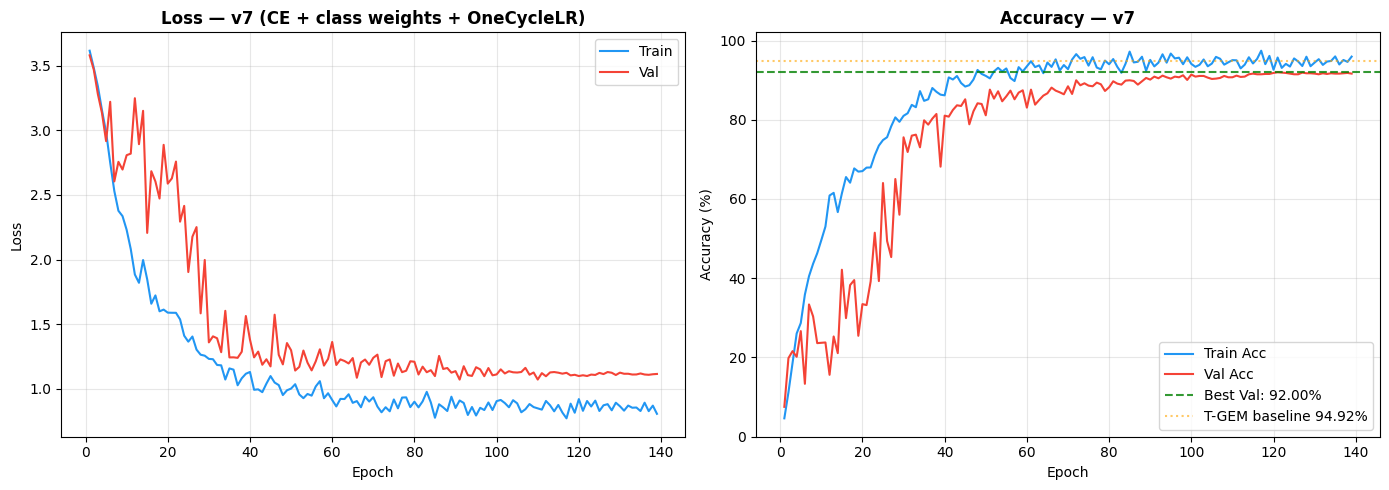

ValueError: not enough values to unpack (expected 5, got 2)

In [10]:
# ── Learning curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
er = range(1, len(history['train_loss']) + 1)

axes[0].plot(er, history['train_loss'], label='Train', color='#2196F3', linewidth=1.5)
axes[0].plot(er, history['val_loss'],   label='Val',   color='#F44336', linewidth=1.5)
axes[0].set_title('Loss — v7 (CE + class weights + OneCycleLR)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(er, history['train_acc'], label='Train Acc', color='#2196F3', linewidth=1.5)
axes[1].plot(er, history['val_acc'],   label='Val Acc',   color='#F44336', linewidth=1.5)
axes[1].axhline(y=best_val_acc, color='green', linestyle='--', alpha=0.8,
                label=f'Best Val: {best_val_acc:.2f}%')
axes[1].axhline(y=94.92, color='orange', linestyle=':', alpha=0.6, label='T-GEM baseline 94.92%')
axes[1].set_title('Accuracy — v7', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_v7.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion matrix (validation) ─────────────────────────────────────────
model.eval()
preds_cm, labels_cm = [], []
with torch.no_grad():
    for mrna, cnv, mut, meth, labels in val_loader:
        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            out = model(mrna.to(DEVICE), cnv.to(DEVICE),
                        mut.to(DEVICE), meth.to(DEVICE))
        preds_cm.extend(out.argmax(1).cpu().numpy())
        labels_cm.extend(labels.numpy())

cm = confusion_matrix(labels_cm, preds_cm)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='gray',
            annot_kws={'size': 7})
ax.set_title(f'Normalised Confusion Matrix — Val Acc {best_val_acc:.2f}%', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('True', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix_v7.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class accuracy bar chart ──────────────────────────────────────────
per_class_acc = cm_norm.diagonal()
sorted_idx    = np.argsort(per_class_acc)
fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#e74c3c' if v < 0.85 else '#f39c12' if v < 0.93 else '#2ecc71'
          for v in per_class_acc[sorted_idx]]
ax.barh([le.classes_[i] for i in sorted_idx], per_class_acc[sorted_idx],
        color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(0.94, color='blue', linestyle='--', alpha=0.7, label='94% target')
ax.set_xlabel('Per-class Accuracy'); ax.set_title('Per-class Accuracy (val)', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('per_class_accuracy_v7.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nClasses below 85% accuracy: '
      f'{[le.classes_[i] for i in np.where(per_class_acc < 0.85)[0]]}')


In [ ]:
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
te_str   = f'{te_acc:.2f}%' if test_loader is not None else 'N/A'
te_mf1_str = f'{te_mf1:.4f}' if test_loader is not None else 'N/A'

print('=' * 72)
print('  FINAL RESULTS — OncoBridge-MMCAT v7')
print('=' * 72)
print(f'  Modalities:     mRNA + CNV + Mutation + Methylation (4-way)')
print(f'  Gene counts:    {gene_k}')
print(f'  Classes:        {CONFIG["num_classes"]}')
print(f'  Parameters:     {n_params:,}')
print(f'  Architecture:   embed=384 | enc_layers=6 | cross_attn=4 | 4 modalities')
print()
print(f'  Val Accuracy:   {best_val_acc:.2f}%')
print(f'  Val Weighted F1:{val_wf1:.4f}')
print(f'  Val Macro F1:   {val_mf1:.4f}')
print(f'  Val MCC:        {val_mcc:.4f}')
print(f'  Test Accuracy:  {te_str}')
print(f'  Test Macro F1:  {te_mf1_str}')
print()
print('  Benchmark comparison:')
print('  ───────────────────────────────────────────────────────────────────')
print('  Model                Acc       Classes  Modalities  Notes')
print('  ───────────────────────────────────────────────────────────────────')
print(f'  OncoBridge v7 (ours){best_val_acc:>7.2f}%   {CONFIG["num_classes"]}       4          This run')
print('  OncoBridge v3       91.94%   22       3          Best 3-mod result')
print('  OncoBridge v4       89.24%   31       3          Focal hurt CE')
print('  OncoBridge v5       83.95%   31       3          Overengineered')
print('  T-GEM               94.92%   33       1 (mRNA)   10,340 samples')
print('  Pathformer (F1)     ~0.73    survival 3          KEGG pathways')
print('  ───────────────────────────────────────────────────────────────────')
print()
print('  Key v7 improvements over all prior versions:')
print('  ✅ Mutation NOT scaled (binary 0/1 — StandardScaler was destroying this)')
print('  ✅ Methylation NOT scaled (beta values [0,1] — already bounded)')
print('  ✅ CNV uses MaxAbsScaler (preserves 0 = normal diploid)')
print('  ✅ 4th modality: DNA methylation (epigenetic silencing signal)')
print('  ✅ Gene importance gate init=1.5 (mostly open, learns to close on noise)')
print('  ✅ Auto-k gene selection (principled, not arbitrary number)')
print('  ✅ OneCycleLR retained (proven in v3, CosineRestarts failed in v5)')
print('  ✅ CE + class weights retained (proven in v3, focal failed in v4)')
print('  ✅ Mixup prob=0.5 retained (v3 proven)')
print()
print('  Next step: Drug Response Prediction')
print('  → Use trained encoder weights as Patient Module')
print('  → Add Drug Module (GNN on SMILES from GDSC/CCLE)')
print('  → Concatenate [patient_vec | drug_vec] → IC50 regression')
print('=' * 72)
